In [1]:
# -*- coding: utf-8 -*-
"""NOTEBOOK 03: ANÁLISIS Y VISUALIZACIÓN DE CLUSTERS
Análisis de Perfiles y Caracterización de Segmentos
"""

# 🔧 Configuración del notebook
import warnings
warnings.filterwarnings('ignore')

print("🚀 Iniciando Notebook 03: Análisis y Visualización de Clusters")

🚀 Iniciando Notebook 03: Análisis y Visualización de Clusters


In [2]:
# ============================================
# 📚 IMPORTACIÓN DE LIBRERÍAS
# ============================================

# 📊 Manipulación y visualización de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 📈 Visualizaciones interactivas (opcional)
# !pip install plotly -q
# import plotly.express as px
# import plotly.graph_objects as go

# 🔧 Configuración de visualizaciones
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.1)

# Configurar tamaño de figuras
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [3]:
# ============================================
# 📂 CARGA DE DATOS CON CLUSTERS
# ============================================

print("📂 Cargando archivo datos_con_clusters.csv...")

# Opción 1: Subir archivo manualmente a Colab
try:
    df = pd.read_csv('datos_con_clusters.csv')
    print("✅ Archivo cargado desde el entorno local")
except:
    # Opción 2: Montar Google Drive (si está en Drive)
    from google.colab import drive
    drive.mount('/content/drive')
    df = pd.read_csv('/content/drive/MyDrive/datos_con_clusters.csv')
    print("✅ Archivo cargado desde Google Drive")

# 📊 Información básica
print("\n" + "="*60)
print("📊 INFORMACIÓN DEL DATASET")
print("="*60)
print(f"📌 Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")

# Verificar que existen las columnas de clusters
cluster_columns = ['cluster_kmeans', 'cluster_dbscan', 'cluster_hierarchical']
for col in cluster_columns:
    if col in df.columns:
        print(f"✅ {col}: presente")
    else:
        print(f"❌ {col}: NO encontrada")

print("\n📋 Primeros registros:")
df.head()

📂 Cargando archivo datos_con_clusters.csv...
✅ Archivo cargado desde el entorno local

📊 INFORMACIÓN DEL DATASET
📌 Dimensiones: 32764 filas × 16 columnas
✅ cluster_kmeans: presente
✅ cluster_dbscan: presente
✅ cluster_hierarchical: presente

📋 Primeros registros:


,PERCEPHO,P103,P104,P105A,EDUCACION_JEFE,DOMINIO,NUM_SERVICIOS,NUM_EQUIPOS,NUM_OCUPADOS,EDAD_JEFE,PCT_NINOS,POBREZA,HACINAMIENTO,cluster_kmeans,cluster_dbscan,cluster_hierarchical
0,2,2.0,4.0,2.0,11.0,4,8,6,1.0,45.0,0.000000,3,2.0,0,-1,0
1,2,5.0,3.0,2.0,6.0,4,8,6,2.0,42.0,0.333333,3,6.0,3,-1,0
2,2,5.0,3.0,2.0,8.0,4,8,6,2.0,44.0,0.333333,3,3.0,3,-1,0
3,1,5.0,2.0,2.0,1.0,4,8,6,1.0,78.0,0.000000,3,1.0,2,-1,0
4,2,5.0,1.0,1.0,10.0,4,8,6,2.0,33.0,0.333333,3,3.0,3,-1,0


📊 DISTRIBUCIÓN DE CLUSTERS

🔹 cluster_kmeans:
   Cluster 0: 5853 (17.9%)
   Cluster 1: 4331 (13.2%)
   Cluster 2: 10360 (31.6%)
   Cluster 3: 6286 (19.2%)
   Cluster 4: 5934 (18.1%)

🔹 cluster_dbscan:
   Ruido (-1): 32682 (99.7%)
   Cluster 0: 13 (0.0%)
   Cluster 1: 8 (0.0%)
   Cluster 2: 12 (0.0%)
   Cluster 3: 8 (0.0%)
   Cluster 4: 7 (0.0%)
   Cluster 5: 8 (0.0%)
   Cluster 6: 12 (0.0%)
   Cluster 7: 7 (0.0%)
   Cluster 8: 7 (0.0%)

🔹 cluster_hierarchical:
   Cluster 0: 32457 (99.1%)
   Cluster 1: 98 (0.3%)
   Cluster 2: 205 (0.6%)
   Cluster 3: 1 (0.0%)
   Cluster 4: 3 (0.0%)


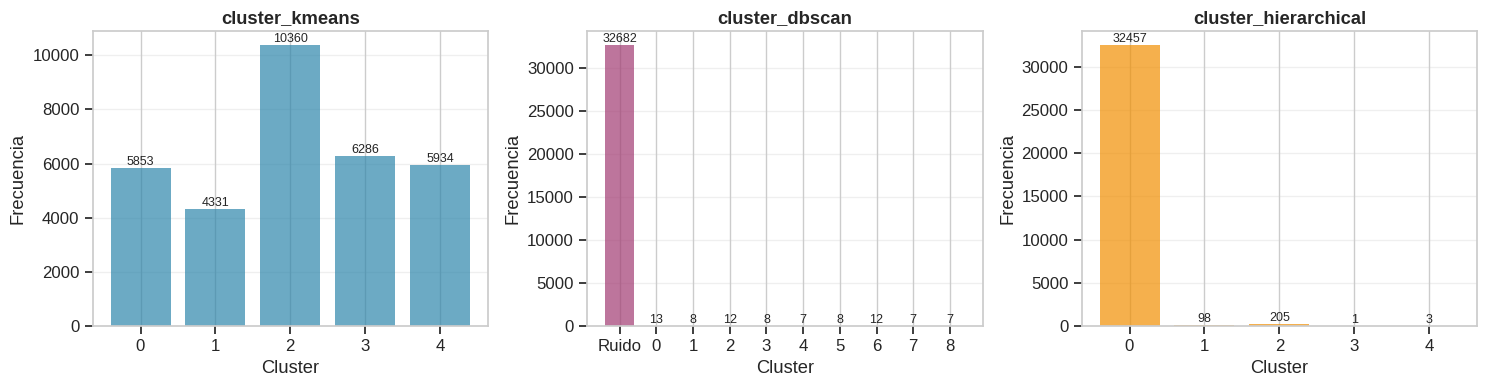


✅ Para el resto del análisis usaremos: cluster_kmeans


In [4]:
# ============================================
# 📊 DESCRIPCIÓN GENERAL DE CLUSTERS
# ============================================

print("="*60)
print("📊 DISTRIBUCIÓN DE CLUSTERS")
print("="*60)

for cluster_col in cluster_columns:
    if cluster_col in df.columns:
        print(f"\n🔹 {cluster_col}:")
        counts = df[cluster_col].value_counts().sort_index()
        for cluster, count in counts.items():
            if cluster_col == 'cluster_dbscan' and cluster == -1:
                print(f"   Ruido (-1): {count} ({count/len(df)*100:.1f}%)")
            else:
                print(f"   Cluster {cluster}: {count} ({count/len(df)*100:.1f}%)")

# 📊 Visualización de distribución
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#2E86AB', '#A23B72', '#F18F01']

for idx, cluster_col in enumerate(cluster_columns):
    if cluster_col in df.columns:
        # Preparar datos
        counts = df[cluster_col].value_counts().sort_index()
        labels = [str(c) if c != -1 else 'Ruido' for c in counts.index]
        values = counts.values

        # Gráfico de barras
        bars = axes[idx].bar(labels, values, color=colors[idx], alpha=0.7)
        axes[idx].set_title(cluster_col, fontweight='bold')
        axes[idx].set_xlabel('Cluster')
        axes[idx].set_ylabel('Frecuencia')
        axes[idx].grid(True, alpha=0.3, axis='y')

        # Agregar valores en barras
        for bar, val in zip(bars, values):
            axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                          str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Seleccionar el método principal para el resto del análisis
metodo_principal = 'cluster_kmeans'  # O 'cluster_hierarchical' si prefieres
print(f"\n✅ Para el resto del análisis usaremos: {metodo_principal}")

In [5]:
# ============================================
# 📊 DESCRIPCIÓN DE CLUSTERS POR VARIABLES
# ============================================

print("="*60)
print("📊 PERFILES DE CLUSTERS (MEDIAS POR VARIABLE)")
print("="*60)

# Seleccionar variables para el perfil (excluir columnas de clusters)
cluster_cols = ['cluster_kmeans', 'cluster_dbscan', 'cluster_hierarchical']
feature_cols = [col for col in df.columns if col not in cluster_cols]

# Crear tabla de perfiles para el método principal
perfil_df = df.groupby(metodo_principal)[feature_cols].mean().round(2)

print(f"\n📋 Tabla de perfiles para {metodo_principal}:")
display(perfil_df)

# También calcular desviación estándar
perfil_std = df.groupby(metodo_principal)[feature_cols].std().round(2)
print(f"\n📋 Desviación estándar por cluster:")
display(perfil_std)

# Guardar tabla de perfiles
perfil_df.to_csv('perfil_clusters.csv')
print("\n✅ Tabla de perfiles guardada: perfil_clusters.csv")

📊 PERFILES DE CLUSTERS (MEDIAS POR VARIABLE)

📋 Tabla de perfiles para cluster_kmeans:


,PERCEPHO,P103,P104,P105A,EDUCACION_JEFE,DOMINIO,NUM_SERVICIOS,NUM_EQUIPOS,NUM_OCUPADOS,EDAD_JEFE,PCT_NINOS,POBREZA,HACINAMIENTO
cluster_kmeans,,,,,,,,,,,,,
0,1.91,3.00,4.33,2.00,8.18,5.09,8.0,6.0,1.40,56.36,0.05,2.99,2.89
1,1.65,4.80,2.56,5.99,6.06,4.97,8.0,6.0,1.38,47.10,0.16,2.80,2.52
2,1.52,5.26,2.75,2.05,4.08,4.74,8.0,6.0,1.19,63.90,0.01,2.80,1.72
3,1.77,5.04,2.72,1.91,5.60,4.98,8.0,6.0,1.56,39.96,0.36,2.57,3.31
4,3.41,4.86,4.29,2.18,5.10,4.66,8.0,6.0,3.08,55.59,0.12,2.77,5.07



📋 Desviación estándar por cluster:


,PERCEPHO,P103,P104,P105A,EDUCACION_JEFE,DOMINIO,NUM_SERVICIOS,NUM_EQUIPOS,NUM_OCUPADOS,EDAD_JEFE,PCT_NINOS,POBREZA,HACINAMIENTO
cluster_kmeans,,,,,,,,,,,,,
0,0.77,1.19,1.70,0.78,2.07,2.64,0.0,0.0,0.80,14.17,0.12,0.12,1.36
1,0.70,1.07,1.26,0.23,2.21,2.25,0.0,0.0,0.77,15.41,0.20,0.46,1.65
2,0.61,0.77,1.30,0.56,1.86,2.18,0.0,0.0,0.75,13.73,0.05,0.48,1.14
3,0.63,0.87,1.28,0.62,1.85,2.31,0.0,0.0,0.71,9.68,0.15,0.64,1.84
4,0.97,1.02,1.65,0.87,1.95,2.46,0.0,0.0,0.98,11.67,0.13,0.49,2.01



✅ Tabla de perfiles guardada: perfil_clusters.csv


In [6]:
# ============================================
# 📊 TABLA DE PERFILES COMPLETA
# ============================================

print("="*60)
print("📊 TABLA DE PERFILES DETALLADA")
print("="*60)

# Crear tabla con estadísticas completas
perfil_completo = pd.DataFrame()

for cluster in sorted(df[metodo_principal].unique()):
    cluster_data = df[df[metodo_principal] == cluster]
    stats = {
        'Cluster': f'Cluster {cluster}',
        'N': len(cluster_data),
        '%': f"{len(cluster_data)/len(df)*100:.1f}%"
    }

    # Agregar medias de variables clave
    for col in feature_cols[:10]:  # Limitamos a las primeras 10 para no saturar
        stats[f'{col}_media'] = cluster_data[col].mean()
        stats[f'{col}_std'] = cluster_data[col].std()

    perfil_completo = pd.concat([perfil_completo, pd.DataFrame([stats])], ignore_index=True)

# Formatear números
for col in perfil_completo.columns:
    if '_media' in col or '_std' in col:
        perfil_completo[col] = perfil_completo[col].round(2)

display(perfil_completo)

# Guardar tabla completa
perfil_completo.to_csv('perfil_clusters_completo.csv', index=False)
print("\n✅ Tabla completa guardada: perfil_clusters_completo.csv")

📊 TABLA DE PERFILES DETALLADA


,Cluster,N,%,PERCEPHO_media,PERCEPHO_std,P103_media,P103_std,P104_media,P104_std,P105A_media,...,DOMINIO_media,DOMINIO_std,NUM_SERVICIOS_media,NUM_SERVICIOS_std,NUM_EQUIPOS_media,NUM_EQUIPOS_std,NUM_OCUPADOS_media,NUM_OCUPADOS_std,EDAD_JEFE_media,EDAD_JEFE_std
0,Cluster 0,5853,17.9%,1.91,0.77,3.00,1.19,4.33,1.70,2.00,...,5.09,2.64,8.0,0.0,6.0,0.0,1.40,0.80,56.36,14.17
1,Cluster 1,4331,13.2%,1.65,0.70,4.80,1.07,2.56,1.26,5.99,...,4.97,2.25,8.0,0.0,6.0,0.0,1.38,0.77,47.10,15.41
2,Cluster 2,10360,31.6%,1.52,0.61,5.26,0.77,2.75,1.30,2.05,...,4.74,2.18,8.0,0.0,6.0,0.0,1.19,0.75,63.90,13.73
3,Cluster 3,6286,19.2%,1.77,0.63,5.04,0.87,2.72,1.28,1.91,...,4.98,2.31,8.0,0.0,6.0,0.0,1.56,0.71,39.96,9.68
4,Cluster 4,5934,18.1%,3.41,0.97,4.86,1.02,4.29,1.65,2.18,...,4.66,2.46,8.0,0.0,6.0,0.0,3.08,0.98,55.59,11.67



✅ Tabla completa guardada: perfil_clusters_completo.csv


📈 VISUALIZACIÓN PCA POR CLUSTER
⚠️ No se encontraron columnas PCA. Calculando PCA ahora...
✅ PCA calculado: varianza explicada = 37.87%


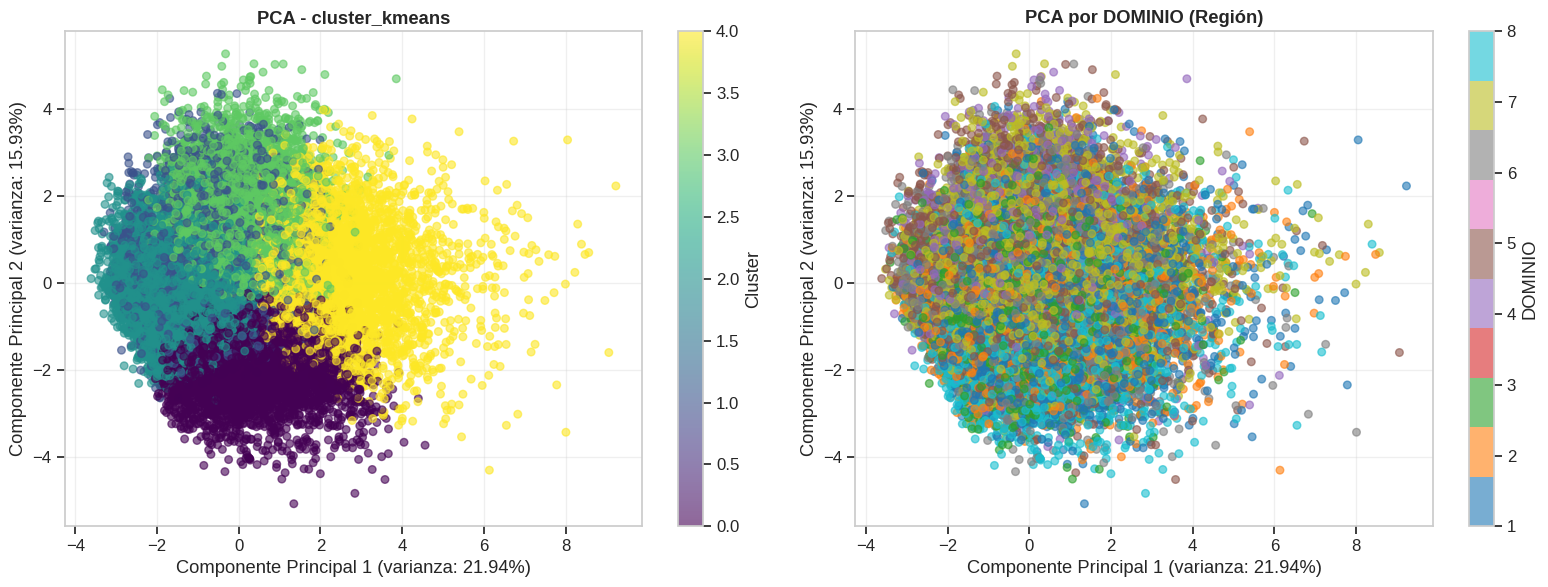

In [7]:
# ============================================
# 📈 VISUALIZACIÓN DE PCA POR CLUSTER
# ============================================

print("="*60)
print("📈 VISUALIZACIÓN PCA POR CLUSTER")
print("="*60)

# Verificar si existen las columnas PCA (si no, las calculamos)
pca_cols = [col for col in df.columns if col.startswith('PC') or col.startswith('pca')]

if len(pca_cols) >= 2:
    print("✅ Usando columnas PCA existentes")
    x_pca = pca_cols[0]
    y_pca = pca_cols[1]
else:
    print("⚠️ No se encontraron columnas PCA. Calculando PCA ahora...")
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler

    # Seleccionar variables numéricas
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    feature_cols = [col for col in numeric_cols if col not in cluster_cols]

    # Normalizar y aplicar PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[feature_cols])
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    df['PCA1'] = X_pca[:, 0]
    df['PCA2'] = X_pca[:, 1]
    x_pca = 'PCA1'
    y_pca = 'PCA2'

    print(f"✅ PCA calculado: varianza explicada = {pca.explained_variance_ratio_.sum():.2%}")

# 📈 Gráfico PCA por cluster
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: PCA por cluster K-Means
scatter1 = axes[0].scatter(df[x_pca], df[y_pca],
                           c=df[metodo_principal], cmap='viridis',
                           alpha=0.6, s=30)
axes[0].set_xlabel(f'Componente Principal 1 (varianza: {pca.explained_variance_ratio_[0]:.2%})')
axes[0].set_ylabel(f'Componente Principal 2 (varianza: {pca.explained_variance_ratio_[1]:.2%})')
axes[0].set_title(f'PCA - {metodo_principal}', fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Gráfico 2: PCA por DOMINIO (región)
if 'DOMINIO' in df.columns:
    scatter2 = axes[1].scatter(df[x_pca], df[y_pca],
                               c=df['DOMINIO'], cmap='tab10',
                               alpha=0.6, s=30)
    axes[1].set_xlabel(f'Componente Principal 1 (varianza: {pca.explained_variance_ratio_[0]:.2%})')
    axes[1].set_ylabel(f'Componente Principal 2 (varianza: {pca.explained_variance_ratio_[1]:.2%})')
    axes[1].set_title('PCA por DOMINIO (Región)', fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=axes[1], label='DOMINIO')

plt.tight_layout()
plt.show()

📈 VISUALIZACIÓN PCA POR REGIÓN (DOMINIO)


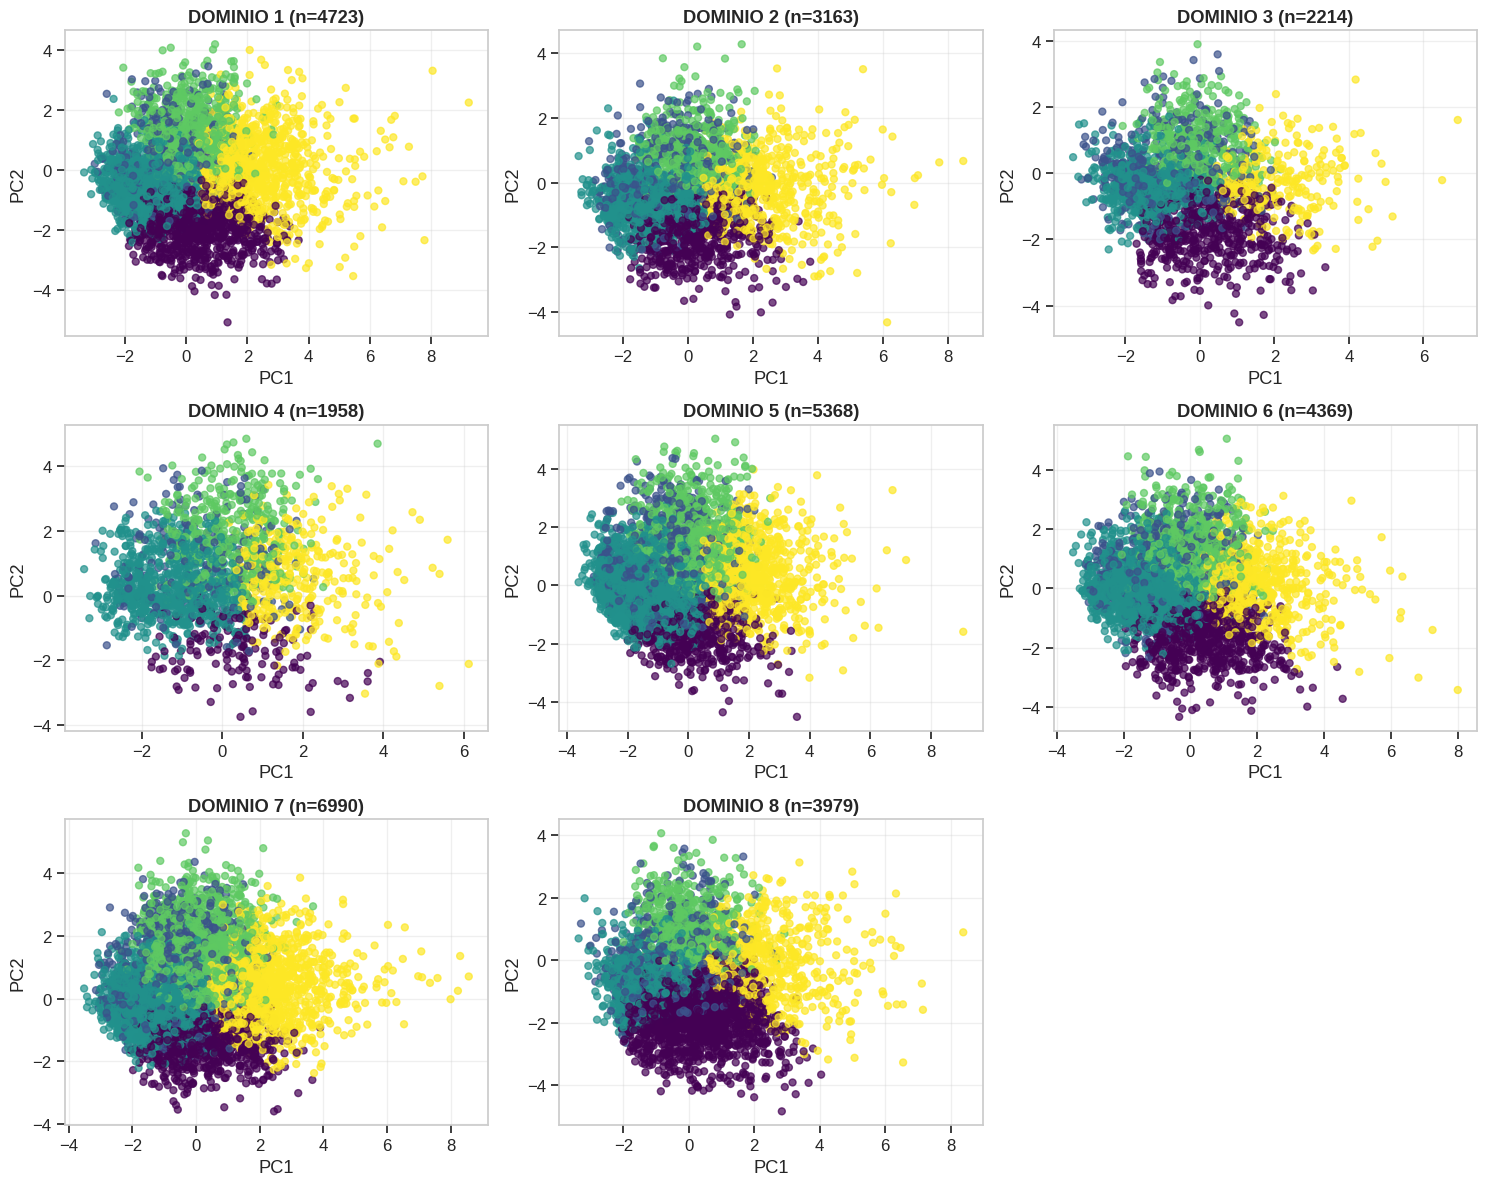


📊 Distribución de clusters por DOMINIO:


cluster_kmeans,0,1,2,3,4
DOMINIO,,,,,
1,907,432,1405,876,1103
2,621,470,938,508,626
3,501,395,643,371,304
4,151,209,799,434,365
5,545,814,2123,995,891
6,705,536,1769,692,667
7,818,947,2021,1850,1354
8,1605,528,662,560,624


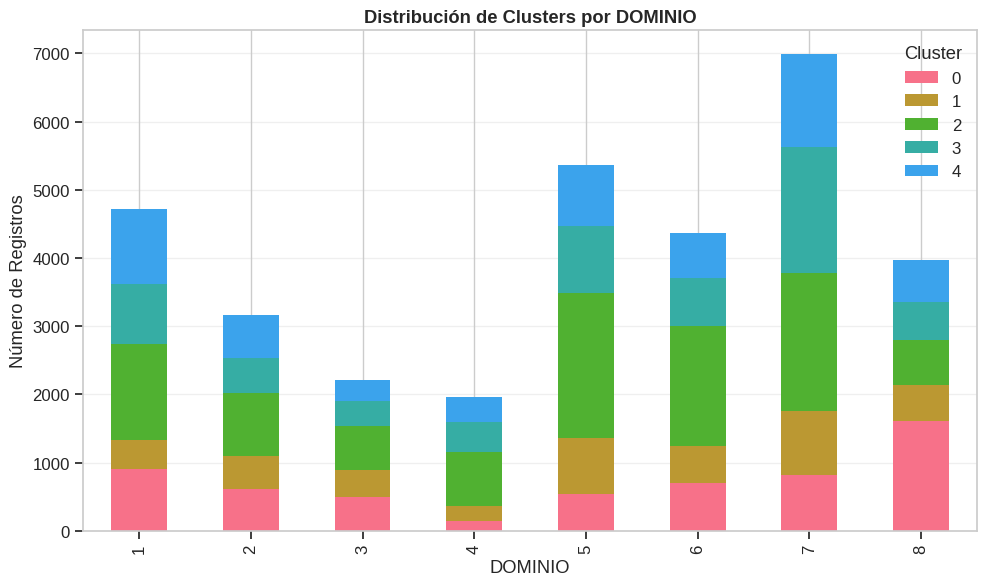

In [8]:
# ============================================
# 📈 VISUALIZACIÓN PCA POR REGIÓN (DOMINIO)
# ============================================

print("="*60)
print("📈 VISUALIZACIÓN PCA POR REGIÓN (DOMINIO)")
print("="*60)

if 'DOMINIO' in df.columns:
    # Crear figura con subplots por DOMINIO
    dominios = sorted(df['DOMINIO'].unique())
    n_dominios = len(dominios)

    # Calcular número de filas y columnas para subplots
    n_cols = min(3, n_dominios)
    n_rows = (n_dominios + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten() if n_dominios > 1 else [axes]

    for idx, dominio in enumerate(dominios):
        mask = df['DOMINIO'] == dominio
        data = df[mask]

        ax = axes[idx]
        scatter = ax.scatter(data[x_pca], data[y_pca],
                            c=data[metodo_principal], cmap='viridis',
                            alpha=0.7, s=25)
        ax.set_title(f'DOMINIO {dominio} (n={len(data)})', fontweight='bold')
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.grid(True, alpha=0.3)

    # Ocultar ejes vacíos
    for idx in range(len(dominios), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

    # 📊 Estadísticas por DOMINIO
    print("\n📊 Distribución de clusters por DOMINIO:")
    cross_tab = pd.crosstab(df['DOMINIO'], df[metodo_principal])
    display(cross_tab)

    # Gráfico de barras apiladas
    cross_tab.plot(kind='bar', stacked=True, figsize=(10, 6))
    plt.title('Distribución de Clusters por DOMINIO', fontweight='bold')
    plt.xlabel('DOMINIO')
    plt.ylabel('Número de Registros')
    plt.legend(title='Cluster')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No se encontró la columna 'DOMINIO'")

📊 BOXPLOTS POR CLUSTER


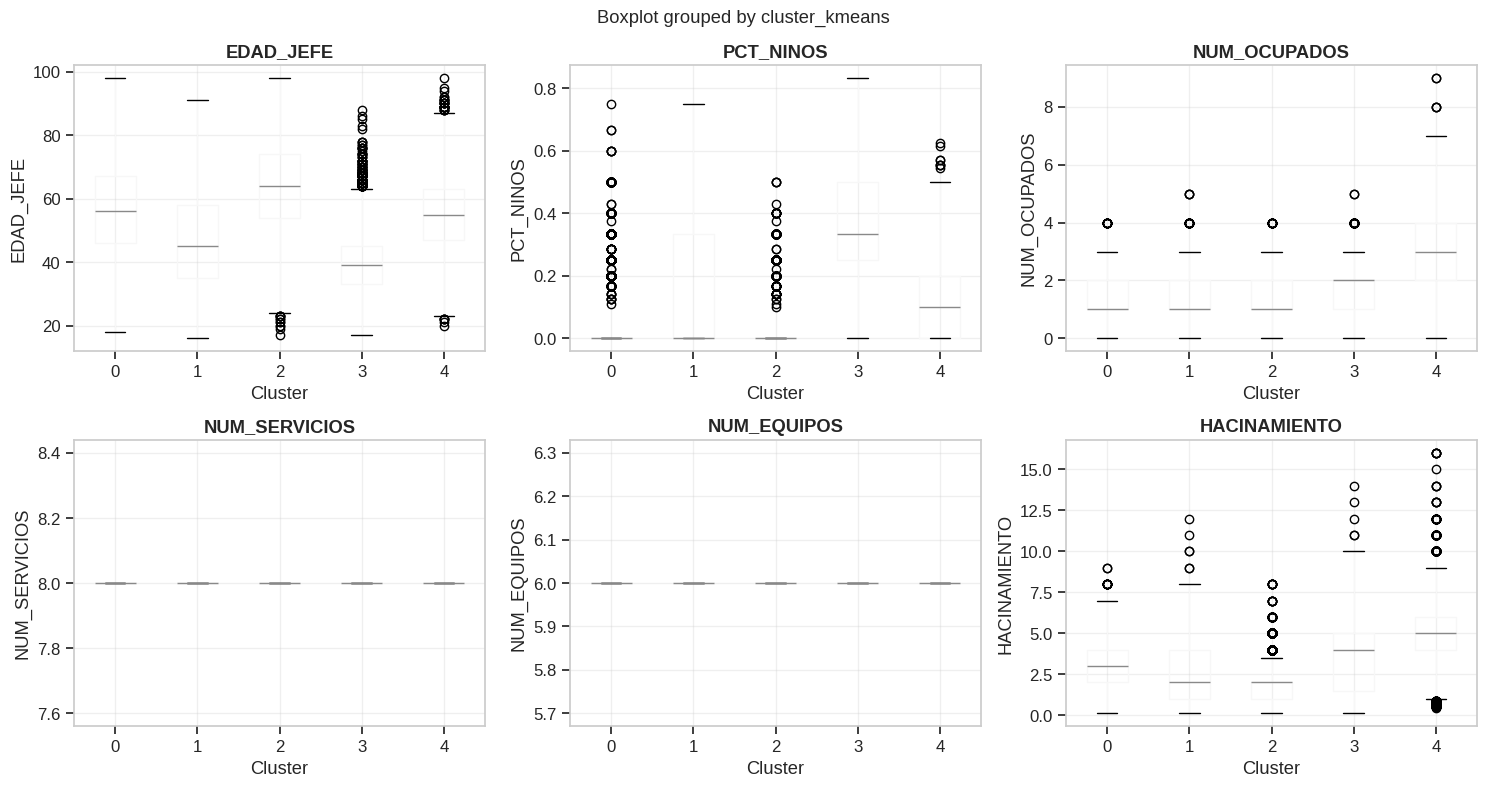

In [9]:
# ============================================
# 📊 BOXPLOTS POR CLUSTER
# ============================================

print("="*60)
print("📊 BOXPLOTS POR CLUSTER")
print("="*60)

# Seleccionar variables clave para visualizar
variables_clave = ['EDAD_JEFE', 'PCT_NINOS', 'NUM_OCUPADOS',
                   'NUM_SERVICIOS', 'NUM_EQUIPOS', 'HACINAMIENTO']

# Filtrar variables que existen en el dataset
variables_graficar = [var for var in variables_clave if var in df.columns]

if variables_graficar:
    n_vars = len(variables_graficar)
    n_cols = min(3, n_vars)
    n_rows = (n_vars + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten() if n_vars > 1 else [axes]

    for idx, var in enumerate(variables_graficar):
        ax = axes[idx]

        # Crear boxplot
        df.boxplot(column=var, by=metodo_principal, ax=ax, grid=False)
        ax.set_title(f'{var}', fontweight='bold')
        ax.set_xlabel('Cluster')
        ax.set_ylabel(var)
        ax.grid(True, alpha=0.3)

    # Ocultar ejes vacíos
    for idx in range(len(variables_graficar), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No se encontraron variables clave para graficar")

📊 HEATMAP DE CORRELACIÓN

📋 Correlación de variables con el cluster:


,cluster_kmeans
cluster_kmeans,1.000000
PCA2,0.470880
NUM_OCUPADOS,0.449988
P103,0.432972
PERCEPHO,0.411388
PCA1,0.375036
HACINAMIENTO,0.352713
PCT_NINOS,0.272044
P104,-0.008958
DOMINIO,-0.046582


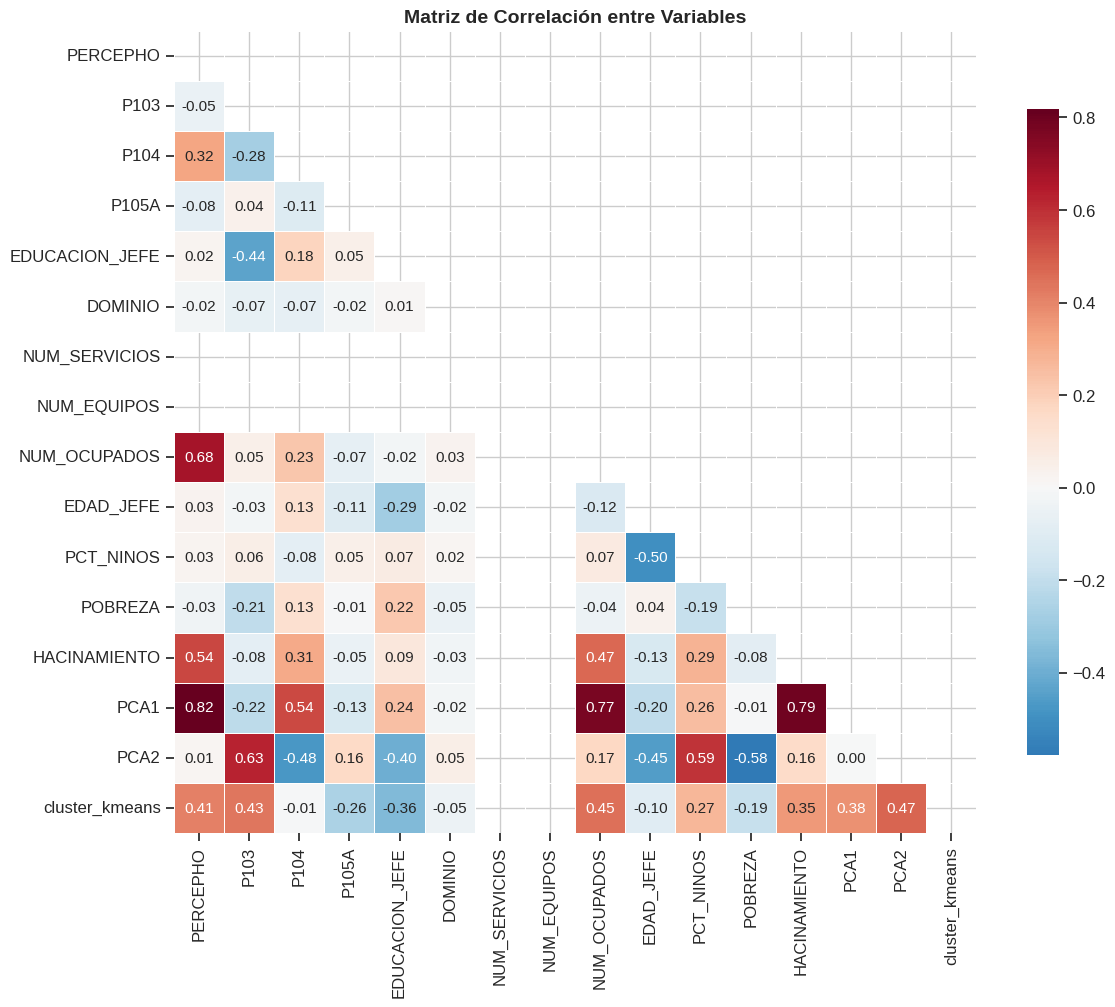

In [10]:
# ============================================
# 📊 HEATMAP DE CORRELACIÓN ENTRE VARIABLES Y CLUSTERS
# ============================================

print("="*60)
print("📊 HEATMAP DE CORRELACIÓN")
print("="*60)

# Seleccionar variables numéricas (excluyendo clusters)
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_cols = [col for col in numeric_cols if col not in cluster_cols]

# Agregar el cluster como variable numérica
corr_df = df[corr_cols + [metodo_principal]].copy()

# Calcular matriz de correlación
corr_matrix = corr_df.corr()

# Filtrar para mostrar solo correlaciones con el cluster
cluster_corr = corr_matrix[[metodo_principal]].sort_values(by=metodo_principal, ascending=False)

print("\n📋 Correlación de variables con el cluster:")
display(cluster_corr)

# 📈 Heatmap de correlaciones
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación entre Variables', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

📊 PERFIL DE CLUSTERS - RADAR CHART


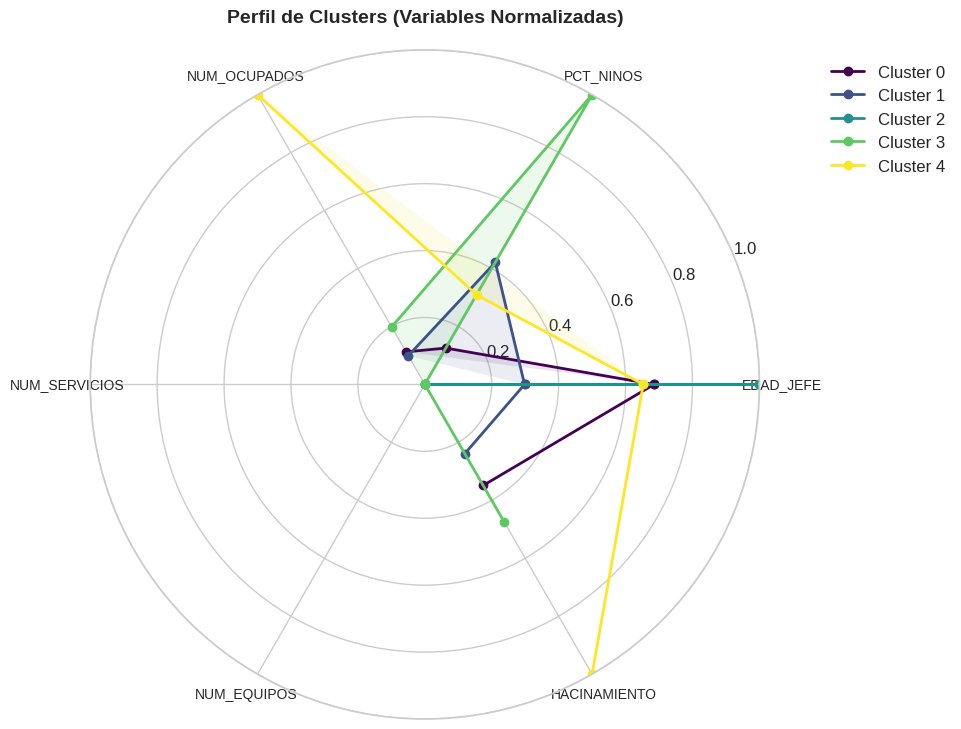

In [11]:
# ============================================
# 📊 PERFIL DE CLUSTERS - RADAR CHART (OPCIONAL)
# ============================================

print("="*60)
print("📊 PERFIL DE CLUSTERS - RADAR CHART")
print("="*60)

# Normalizar variables para el radar chart
variables_radar = ['EDAD_JEFE', 'PCT_NINOS', 'NUM_OCUPADOS',
                   'NUM_SERVICIOS', 'NUM_EQUIPOS', 'HACINAMIENTO']

variables_radar = [var for var in variables_radar if var in df.columns]

if len(variables_radar) >= 3:
    # Calcular medias por cluster y normalizar
    radar_data = df.groupby(metodo_principal)[variables_radar].mean()

    # Normalizar Min-Max
    radar_normalized = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

    # Configurar gráfico radar
    angles = np.linspace(0, 2 * np.pi, len(variables_radar), endpoint=False).tolist()
    angles += angles[:1]  # Cerrar el círculo

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

    colors = plt.cm.viridis(np.linspace(0, 1, len(radar_normalized)))

    for idx, (cluster, row) in enumerate(radar_normalized.iterrows()):
        values = row.tolist()
        values += values[:1]  # Cerrar el círculo

        ax.plot(angles, values, 'o-', linewidth=2,
                label=f'Cluster {cluster}', color=colors[idx])
        ax.fill(angles, values, alpha=0.1, color=colors[idx])

    # Configurar etiquetas
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(variables_radar, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title('Perfil de Clusters (Variables Normalizadas)',
                 fontweight='bold', fontsize=14, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Se necesitan al menos 3 variables para el radar chart")

📊 ANÁLISIS DE POBREZA POR CLUSTER

📋 Distribución de POBREZA por cluster:


POBREZA,1,2,3
cluster_kmeans,,,
0,4,69,5780
1,103,663,3565
2,341,1390,8629
3,528,1671,4087
4,185,999,4750



📋 Porcentaje de POBREZA por cluster:


POBREZA,1,2,3
cluster_kmeans,,,
0,0.07,1.18,98.75
1,2.38,15.31,82.31
2,3.29,13.42,83.29
3,8.40,26.58,65.02
4,3.12,16.84,80.05


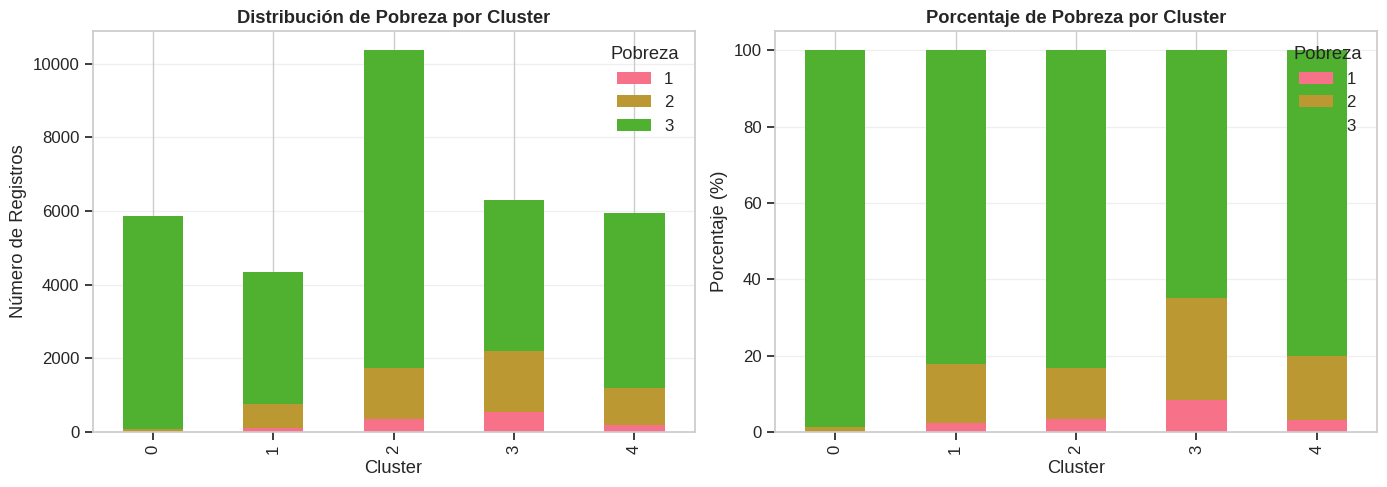

In [12]:
# ============================================
# 📊 ANÁLISIS DE POBREZA POR CLUSTER
# ============================================

print("="*60)
print("📊 ANÁLISIS DE POBREZA POR CLUSTER")
print("="*60)

if 'POBREZA' in df.columns:
    # Distribución de pobreza por cluster
    poverty_by_cluster = df.groupby([metodo_principal, 'POBREZA']).size().unstack(fill_value=0)

    print("\n📋 Distribución de POBREZA por cluster:")
    display(poverty_by_cluster)

    # Porcentajes
    poverty_pct = poverty_by_cluster.div(poverty_by_cluster.sum(axis=1), axis=0) * 100
    print("\n📋 Porcentaje de POBREZA por cluster:")
    display(poverty_pct.round(2))

    # 📈 Gráfico de barras apiladas
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico 1: Conteos
    poverty_by_cluster.plot(kind='bar', ax=axes[0], stacked=True)
    axes[0].set_title('Distribución de Pobreza por Cluster', fontweight='bold')
    axes[0].set_xlabel('Cluster')
    axes[0].set_ylabel('Número de Registros')
    axes[0].legend(title='Pobreza')
    axes[0].grid(True, alpha=0.3, axis='y')

    # Gráfico 2: Porcentajes
    poverty_pct.plot(kind='bar', ax=axes[1], stacked=True)
    axes[1].set_title('Porcentaje de Pobreza por Cluster', fontweight='bold')
    axes[1].set_xlabel('Cluster')
    axes[1].set_ylabel('Porcentaje (%)')
    axes[1].legend(title='Pobreza')
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No se encontró la columna 'POBREZA'")

📊 PAIRPLOT DE VARIABLES CLAVE POR CLUSTER


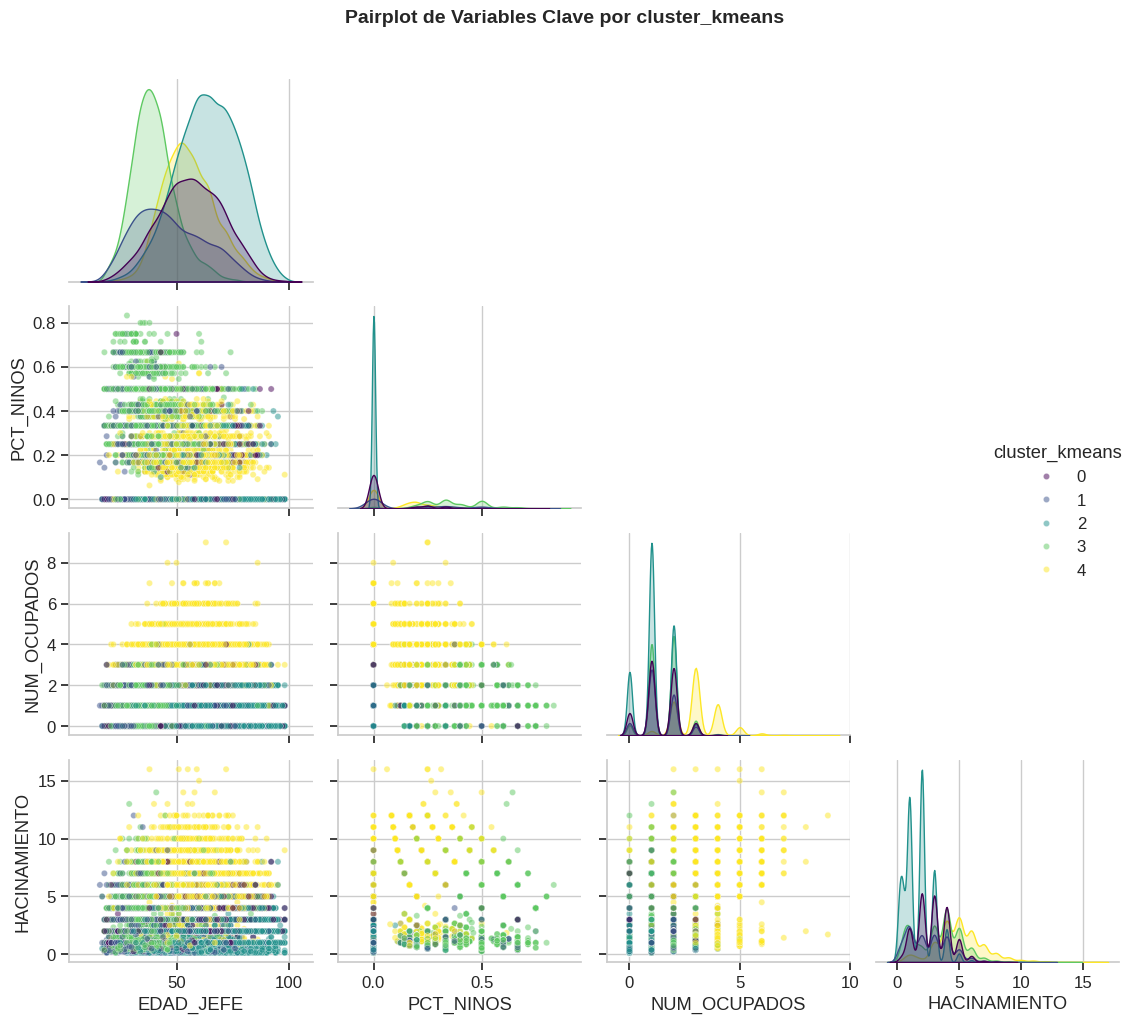

In [13]:
# ============================================
# 📊 VISUALIZACIÓN POR CLUSTER - PAIRPLOT
# ============================================

print("="*60)
print("📊 PAIRPLOT DE VARIABLES CLAVE POR CLUSTER")
print("="*60)

# Seleccionar variables para pairplot
pairplot_vars = ['EDAD_JEFE', 'PCT_NINOS', 'NUM_OCUPADOS', 'HACINAMIENTO']
pairplot_vars = [var for var in pairplot_vars if var in df.columns]

if len(pairplot_vars) >= 2:
    # Crear pairplot
    g = sns.pairplot(df[pairplot_vars + [metodo_principal]],
                     hue=metodo_principal,
                     palette='viridis',
                     diag_kind='kde',
                     corner=True,
                     plot_kws={'alpha': 0.5, 's': 20})

    g.fig.suptitle(f'Pairplot de Variables Clave por {metodo_principal}',
                   fontweight='bold', fontsize=14, y=1.02)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Se necesitan al menos 2 variables para el pairplot")

In [14]:
# ============================================
# 📊 INTERPRETACIÓN Y DESCRIPCIÓN DE CLUSTERS
# ============================================

print("="*60)
print("📊 INTERPRETACIÓN DE CLUSTERS")
print("="*60)

# Obtener medias por cluster
cluster_means = df.groupby(metodo_principal)[feature_cols].mean()

print("\n📋 Características de cada cluster:\n")

for cluster in sorted(df[metodo_principal].unique()):
    print(f"\n🔸 CLUSTER {cluster} (n={len(df[df[metodo_principal]==cluster])})")
    print("-" * 50)

    # Obtener características del cluster
    cluster_data = cluster_means.loc[cluster]

    # Identificar características distintivas (alto/bajo)
    global_means = df[feature_cols].mean()

    # Variables con valores altos (más de 1 desviación estándar por encima)
    high_vars = []
    low_vars = []

    for var in feature_cols:
        if var in cluster_data.index and var in global_means.index:
            if cluster_data[var] > global_means[var] + global_means[var]*0.3:
                high_vars.append((var, cluster_data[var]))
            elif cluster_data[var] < global_means[var] - global_means[var]*0.3:
                low_vars.append((var, cluster_data[var]))

    if high_vars:
        print("  📈 Características ALTAS:")
        for var, val in high_vars[:5]:
            print(f"     • {var}: {val:.2f}")

    if low_vars:
        print("  📉 Características BAJAS:")
        for var, val in low_vars[:5]:
            print(f"     • {var}: {val:.2f}")

    # Mostrar valores clave
    print("  📊 Valores clave:")
    key_vars = ['EDAD_JEFE', 'PCT_NINOS', 'NUM_OCUPADOS', 'HACINAMIENTO', 'POBREZA']
    for var in key_vars:
        if var in cluster_data.index:
            print(f"     • {var}: {cluster_data[var]:.2f}")

📊 INTERPRETACIÓN DE CLUSTERS

📋 Características de cada cluster:


🔸 CLUSTER 0 (n=5853)
--------------------------------------------------
  📈 Características ALTAS:
     • P104: 4.33
     • EDUCACION_JEFE: 8.18
  📉 Características BAJAS:
     • P103: 3.00
     • PCT_NINOS: 0.05
  📊 Valores clave:
     • EDAD_JEFE: 56.36
     • PCT_NINOS: 0.05
     • NUM_OCUPADOS: 1.40
     • HACINAMIENTO: 2.89
     • POBREZA: 2.99

🔸 CLUSTER 1 (n=4331)
--------------------------------------------------
  📈 Características ALTAS:
     • P105A: 5.99
  📊 Valores clave:
     • EDAD_JEFE: 47.10
     • PCT_NINOS: 0.16
     • NUM_OCUPADOS: 1.38
     • HACINAMIENTO: 2.52
     • POBREZA: 2.80

🔸 CLUSTER 2 (n=10360)
--------------------------------------------------
  📉 Características BAJAS:
     • PCT_NINOS: 0.01
     • HACINAMIENTO: 1.72
  📊 Valores clave:
     • EDAD_JEFE: 63.90
     • PCT_NINOS: 0.01
     • NUM_OCUPADOS: 1.19
     • HACINAMIENTO: 1.72
     • POBREZA: 2.80

🔸 CLUSTER 3 (n=6286)
------------

In [15]:
# ============================================
# 💾 GUARDAR RESULTADOS
# ============================================

print("💾 Guardando resultados del análisis...")

# 1. Tabla de perfiles
perfil_df.to_csv('perfil_clusters.csv', index=True)
print("✅ perfil_clusters.csv")

# 2. Tabla completa
perfil_completo.to_csv('perfil_clusters_completo.csv', index=False)
print("✅ perfil_clusters_completo.csv")

# 3. Datos con clusters (ya existe, pero lo guardamos por si acaso)
df.to_csv('datos_con_clusters_v2.csv', index=False)
print("✅ datos_con_clusters_v2.csv")

print("\n" + "="*60)
print("📊 RESUMEN FINAL DEL ANÁLISIS")
print("="*60)

print(f"\n📌 MÉTODO UTILIZADO: {metodo_principal}")
print(f"📌 NÚMERO DE CLUSTERS: {len(df[metodo_principal].unique())}")

# Distribución de clusters
print("\n📌 DISTRIBUCIÓN DE CLUSTERS:")
for cluster, count in df[metodo_principal].value_counts().sort_index().items():
    print(f"   Cluster {cluster}: {count} ({count/len(df)*100:.1f}%)")

# Variables más distintivas
print("\n📌 VARIABLES MÁS DISTINTIVAS:")
cluster_means = df.groupby(metodo_principal)[feature_cols].mean()
global_means = df[feature_cols].mean()

# Calcular diferencias relativas
diff_vars = {}
for var in feature_cols:
    if var in cluster_means.columns and var in global_means.index:
        max_diff = max(abs(cluster_means[var] - global_means[var]) / (global_means[var] + 0.001))
        diff_vars[var] = max_diff

top_vars = sorted(diff_vars.items(), key=lambda x: x[1], reverse=True)[:5]
for var, diff in top_vars:
    print(f"   • {var}: diferencia relativa {diff:.2f}")

print("\n✅ Análisis completado exitosamente!")

💾 Guardando resultados del análisis...
✅ perfil_clusters.csv
✅ perfil_clusters_completo.csv
✅ datos_con_clusters_v2.csv

📊 RESUMEN FINAL DEL ANÁLISIS

📌 MÉTODO UTILIZADO: cluster_kmeans
📌 NÚMERO DE CLUSTERS: 5

📌 DISTRIBUCIÓN DE CLUSTERS:
   Cluster 0: 5853 (17.9%)
   Cluster 1: 4331 (13.2%)
   Cluster 2: 10360 (31.6%)
   Cluster 3: 6286 (19.2%)
   Cluster 4: 5934 (18.1%)

📌 VARIABLES MÁS DISTINTIVAS:
   • PCT_NINOS: diferencia relativa 1.91
   • P105A: diferencia relativa 1.34
   • NUM_OCUPADOS: diferencia relativa 0.85
   • HACINAMIENTO: diferencia relativa 0.72
   • PERCEPHO: diferencia relativa 0.71

✅ Análisis completado exitosamente!


In [16]:
# ============================================
# 📥 DESCARGAR ARCHIVOS (SOLO COLAB)
# ============================================

try:
    from google.colab import files

    archivos = ['perfil_clusters.csv', 'perfil_clusters_completo.csv', 'datos_con_clusters_v2.csv']

    print("📥 Descargando archivos generados...")
    for archivo in archivos:
        try:
            files.download(archivo)
            print(f"✅ {archivo} descargado")
        except:
            print(f"⚠️ No se pudo descargar {archivo}")

except:
    print("⚠️ Esta función solo está disponible en Google Colab")
    print("📁 Puedes descargar los archivos manualmente desde el panel de archivos")

📥 Descargando archivos generados...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ perfil_clusters.csv descargado


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ perfil_clusters_completo.csv descargado


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ datos_con_clusters_v2.csv descargado
